In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, make_scorer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# 1. Print the folder Python is currently looking at
print("Current Working Directory:", os.getcwd())

Current Working Directory: C:\Users\Simon\Berkley


In [5]:
# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
print("Loading data...")
df = pd.read_csv('PlayerEngagement.csv')

# --- DATA OVERVIEW SECTION ---
print("\n" + "="*40)
print("📊 QUICK DATA OVERVIEW")
print("="*40)
print(f"Total Players in Dataset: {df.shape[0]:,}")
print(f"Total Features Collected: {df.shape[1]}")

# Calculate Retention Rate
retention_rate = (df['days_played'] >= 7).mean() * 100
print(f"Overall 7-Day Retention Rate: {retention_rate:.2f}%")

# Country Breakdown
top_countries = df['country'].value_counts().head(3)
print("\nTop 3 Countries by Player Count:")
print(top_countries)

# Check for missing values before handling
missing_total = df.isnull().sum().sum()
print(f"\nTotal Missing Values Found: {missing_total}")
print("="*40 + "\n")

# Handle Missing Values
df['country'] = df['country'].fillna('Unknown')

# Process Dates & Extract Features
df['firstplay_date'] = pd.to_datetime(df['firstplay_date'])
df['firstplay_month'] = df['firstplay_date'].dt.month
df['firstplay_dow'] = df['firstplay_date'].dt.day_name()
df['is_weekend'] = df['firstplay_dow'].isin(['Saturday', 'Sunday']).astype(int)

# Aggregations (Summing up Gold and Items)
gold_cols = [c for c in df.columns if c.endswith('_gold')]
item_cols = [c for c in df.columns if c.endswith('_items')]
df['total_gold'] = df[gold_cols].sum(axis=1)
df['total_items'] = df[item_cols].sum(axis=1)

# Log Transformations (Adding 1 to avoid log of zero)
df['log_tot_sess_seconds'] = np.log1p(df['tot_sess_seconds'])
df['log_total_gold'] = np.log1p(df['total_gold'])
df['log_total_items'] = np.log1p(df['total_items'])

# Define target variable (7-day retention)
threshold = 7
df['is_retained'] = (df['days_played'] >= threshold).astype(int)

Loading data...

📊 QUICK DATA OVERVIEW
Total Players in Dataset: 500,000
Total Features Collected: 33
Overall 7-Day Retention Rate: 7.35%

Top 3 Countries by Player Count:
country
US    134195
FR     42497
CN     30466
Name: count, dtype: int64

Total Missing Values Found: 26



In [6]:
# ==========================================
# 2. FEATURE SELECTION & SCALING
# ==========================================
print("Splitting and scaling data...")
numerical_cols = [
    'avg_sessions', 'quest_speed', 'quest_starts',
    'total_gold', 'total_items', 
    'log_tot_sess_seconds', 'log_total_gold', 'log_total_items',
    'visits', 'groups'
]

X = df[numerical_cols]
y = df['is_retained']

# Split FIRST to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit scaler ONLY on training data, then transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames to keep column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numerical_cols)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=numerical_cols)

# Define actionable features (Dropping time and session counts)
actionable_cols = [
    'quest_speed', 'quest_starts',
    'total_gold', 'total_items', 
    'groups',
]

# Slice DataFrames to only include actionable columns
X_train_actionable = X_train_scaled_df[actionable_cols]
X_test_actionable = X_test_scaled_df[actionable_cols]

Splitting and scaling data...


In [7]:
# ==========================================
# 3. AUTOMATIC OPTIMIZATION (GRID SEARCH)
# ==========================================
print("\nSetting up Triple Grid Search...")

# We tell the Grid Search to optimize specifically for Precision
precision_scorer = make_scorer(precision_score, zero_division=0)

# Define the configurations and grids for our three models
model_configs = {
    "Logistic Regression": {
        "model": LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear', random_state=42),
        "params": {
            "C": [0.01, 0.1, 1, 10],          # Regularization strength
            "penalty": ['l1', 'l2']           # Type of regularization
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42),
        "params": {
            "n_estimators": [100, 200],       # Number of trees
            "max_depth": [10, 20, None],      # Tree depth
            "min_samples_split": [2, 5]       # Node splitting strictness
        }
    },
    "XGBoost": {
        "model": XGBClassifier(scale_pos_weight=12, random_state=42, eval_metric='logloss'),
        "params": {
            "learning_rate": [0.01, 0.1],     # Step size
            "max_depth": [3, 6],              # Tree depth
            "gamma": [0, 1, 5]                # Conservativeness parameter for precision
        }
    }
}

best_models = {}
comparison_results = []

print("🔥 Starting Model Optimization Battle...")

# Loop through each model and run its specific Grid Search
for name, config in model_configs.items():
    print(f"\nOptimizing {name}...")
    
    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        scoring=precision_scorer,
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    
    # Fit the grid search to our data
    grid.fit(X_train_actionable, y_train)
    
    # Store the absolute best version of this model
    best_models[name] = grid.best_estimator_
    
    # Evaluate the winning model on the completely unseen test data
    y_pred = grid.best_estimator_.predict(X_test_actionable)
    
    comparison_results.append({
        "Model": name,
        "Best Params": str(grid.best_params_),
        "Test Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred, zero_division=0),
        "Test F1-Score": f1_score(y_test, y_pred, zero_division=0)
    })


Setting up Triple Grid Search...
🔥 Starting Model Optimization Battle...

Optimizing Logistic Regression...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Optimizing Random Forest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Optimizing XGBoost...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [8]:
#==========================================
# 4. RESULTS & COMPARISON
# ==========================================
# Convert our results into a clean dataframe and sort by whoever got the highest Precision
comparison_df = pd.DataFrame(comparison_results).sort_values(by="Test Precision", ascending=False)

print("\n--- Final Optimized Model Comparison ---")
# Setting pandas options just to make sure the Best Params column doesn't get cut off in the console
pd.set_option('display.max_colwidth', None)
print(comparison_df.to_string(index=False))


--- Final Optimized Model Comparison ---
              Model                                                      Best Params  Test Precision  Test Recall  Test F1-Score
      Random Forest {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}        0.826970     0.670657       0.740656
Logistic Regression                                        {'C': 1, 'penalty': 'l2'}        0.547073     0.904320       0.681730
            XGBoost              {'gamma': 5, 'learning_rate': 0.01, 'max_depth': 6}        0.500679     0.929073       0.650697


In [9]:
# ==========================================
# 4. PREPARE DATA FOR GRAPHING
# ==========================================
# Extract importances from the Winning Random Forest
actionable_importances = pd.DataFrame({
    'Feature': actionable_cols,
    'Importance': best_models["Random Forest"].feature_importances_
}).sort_values(by='Importance', ascending=False)



Generating Graphs...


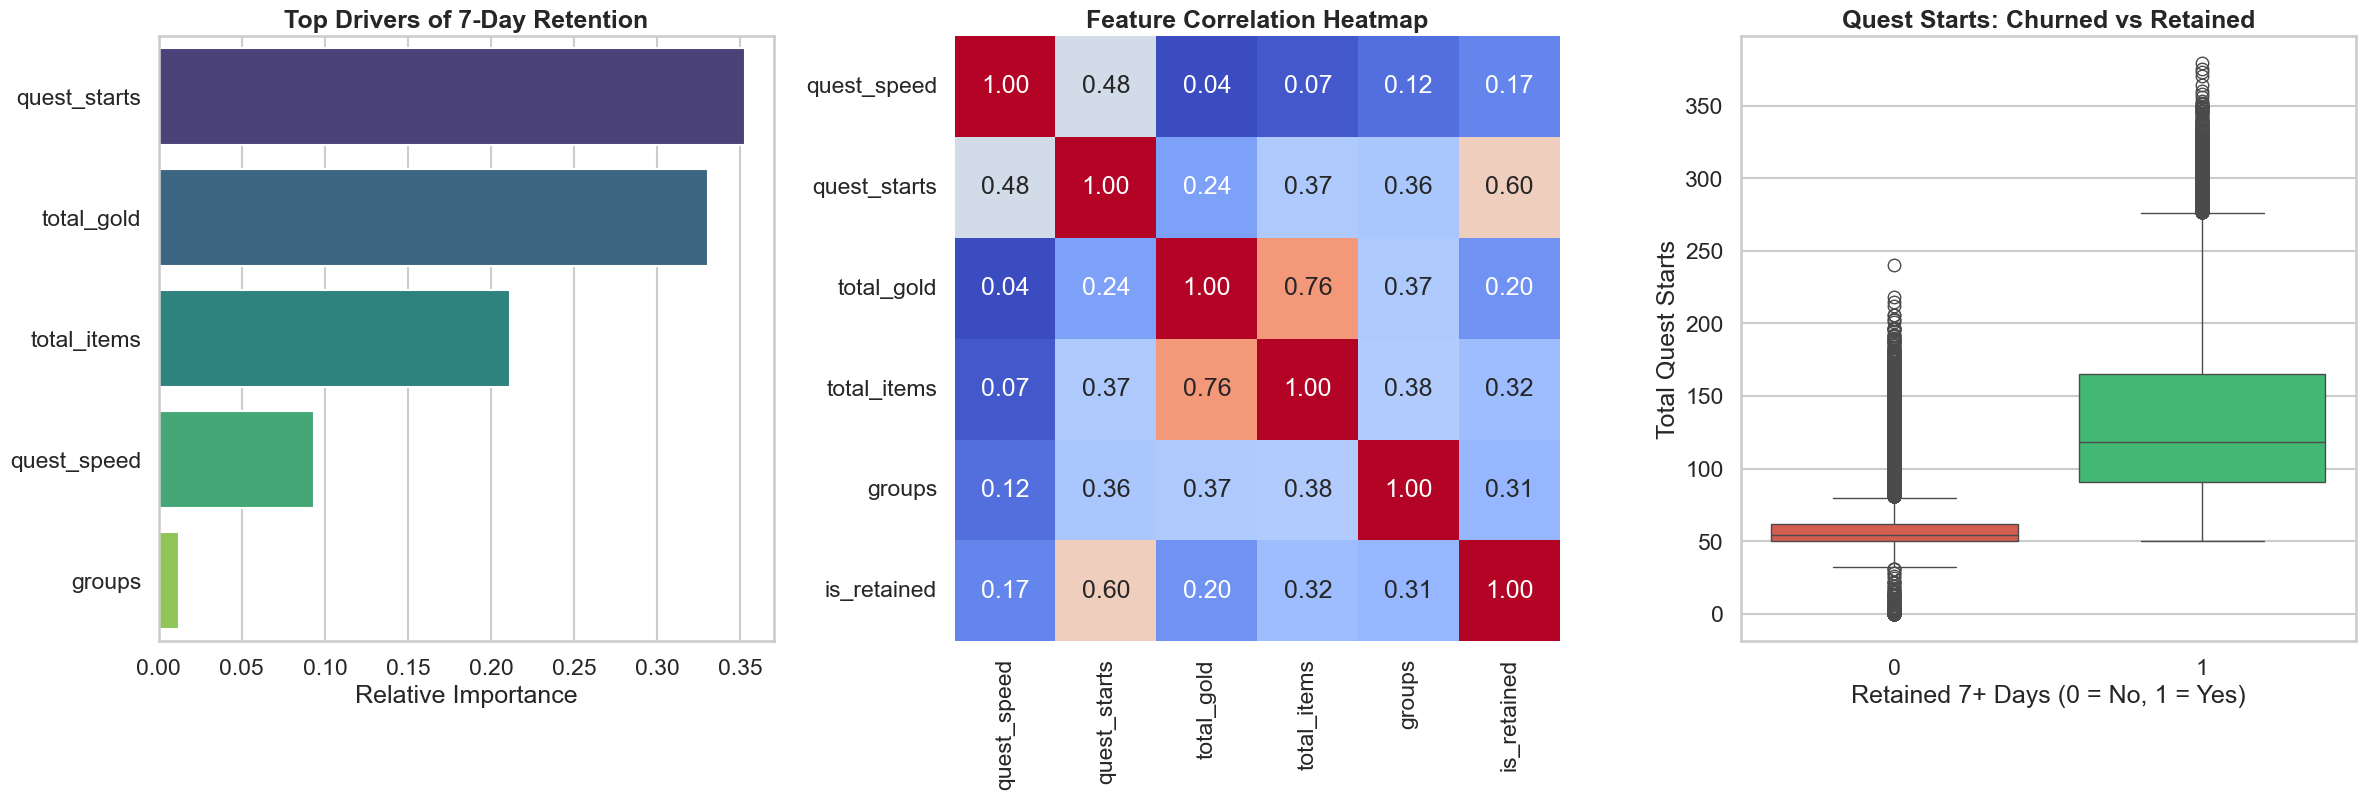

In [10]:
# ==========================================
# 5. GRAPHING
# ==========================================
print("\nGenerating Graphs...")
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# GRAPH 1: Feature Importances
sns.barplot(
    data=actionable_importances, 
    x='Importance', 
    y='Feature', 
    hue='Feature',
    palette='viridis', 
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Top Drivers of 7-Day Retention', fontweight='bold')
axes[0].set_xlabel('Relative Importance')
axes[0].set_ylabel('')

# GRAPH 2: Correlation Heatmap
heatmap_cols = actionable_cols + ['is_retained']
corr_matrix = df[heatmap_cols].corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    cbar=False, 
    square=True,
    ax=axes[1]
)
axes[1].set_title('Feature Correlation Heatmap', fontweight='bold')

# GRAPH 3: Retained vs Churned Boxplot
sns.boxplot(
    data=df, 
    x='is_retained', 
    y='quest_starts', 
    hue='is_retained',
    palette={0: "#e74c3c", 1: "#2ecc71"}, 
    legend=False,
    ax=axes[2]
)
axes[2].set_title('Quest Starts: Churned vs Retained', fontweight='bold')
axes[2].set_xlabel('Retained 7+ Days (0 = No, 1 = Yes)')
axes[2].set_ylabel('Total Quest Starts')

plt.tight_layout()
plt.show()